In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
funds = pd.read_csv("data/processed/01_fund_master_cleaned.csv")
nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")
investors = pd.read_csv("data/processed/08_investor_transactions_cleaned.csv")
portfolio = pd.read_csv("data/processed/09_portfolio_holdings_cleaned.csv")
print("Funds:", funds.shape)
print("NAV:", nav.shape)
print("Investors:", investors.shape)
print("Portfolio:", portfolio.shape)

Funds: (40, 15)
NAV: (46000, 3)
Investors: (32778, 13)
Portfolio: (322, 8)


In [5]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [6]:
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = (nav.groupby('amfi_code')['nav'].pct_change())
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [7]:
risk_metrics = []
for fund in nav['amfi_code'].unique():
    temp = nav[nav['amfi_code'] == fund]
    returns = temp['daily_return'].dropna()
    if len(returns) > 0:
        var95 = np.percentile(returns, 5)
        cvar95 = returns[returns <= var95].mean()
        risk_metrics.append([ fund,var95,cvar95])

risk_df = pd.DataFrame(risk_metrics,columns=['amfi_code', 'VaR_95', 'CVaR_95'])
risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
risk_df.to_csv("reports/var_cvar_report.csv",index=False)
print("Report Saved Successfully")

Report Saved Successfully


In [9]:
print(investors.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [10]:
investors['transaction_date'] = pd.to_datetime(investors['transaction_date'])
first_txn = investors.groupby('investor_id')['transaction_date'].min().reset_index()
first_txn['cohort_year'] = (first_txn['transaction_date'].dt.year)
investors = investors.merge(first_txn[['investor_id', 'cohort_year']],on='investor_id')
investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [11]:
cohort_summary = investors.groupby('cohort_year').agg(avg_investment=('amount_inr', 'mean'),total_invested=('amount_inr', 'sum')).reset_index()
cohort_summary

,cohort_year,avg_investment,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [12]:
top_fund = investors.groupby(['cohort_year', 'amfi_code'])['amount_inr'].sum().reset_index()

top_fund = top_fund.loc[top_fund.groupby('cohort_year')['amount_inr'].idxmax()]

top_fund

,cohort_year,amfi_code,amount_inr
6,2024,102885,100126141
62,2025,119599,1478507


In [13]:
print(funds.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [14]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [15]:
sip_continuity['status'].value_counts()

NameError: name 'sip_continuity' is not defined

In [17]:
sip = investors[investors['transaction_type'] == 'SIP'].copy()

results = []

for investor in sip['investor_id'].unique():

    temp = sip[sip['investor_id'] == investor].sort_values('transaction_date')

    if len(temp) >= 6:
        avg_gap = temp['transaction_date'].diff().dt.days.mean()
        status = "At-Risk" if avg_gap > 35 else "Active"
        results.append([investor, avg_gap, status])
sip_continuity = pd.DataFrame(results,columns=['investor_id', 'avg_gap_days', 'status'])
sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV003054,78.666667,At-Risk
1,INV001497,63.000000,At-Risk
2,INV000786,64.125000,At-Risk
3,INV003670,70.857143,At-Risk
4,INV001023,72.428571,At-Risk


In [18]:
sip_continuity['status'].value_counts()

status
At-Risk    1332
Active       30
Name: count, dtype: int64

In [19]:
print(funds.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [20]:
portfolio['weight_pct'] = portfolio['weight_pct'] / 100 
hhi_df = portfolio.groupby('amfi_code')['weight_pct'].apply(lambda x: (x**2).sum()).reset_index()
hhi_df.columns = ['amfi_code', 'HHI']
hhi_df = hhi_df.sort_values('HHI',ascending=False)
hhi_df.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


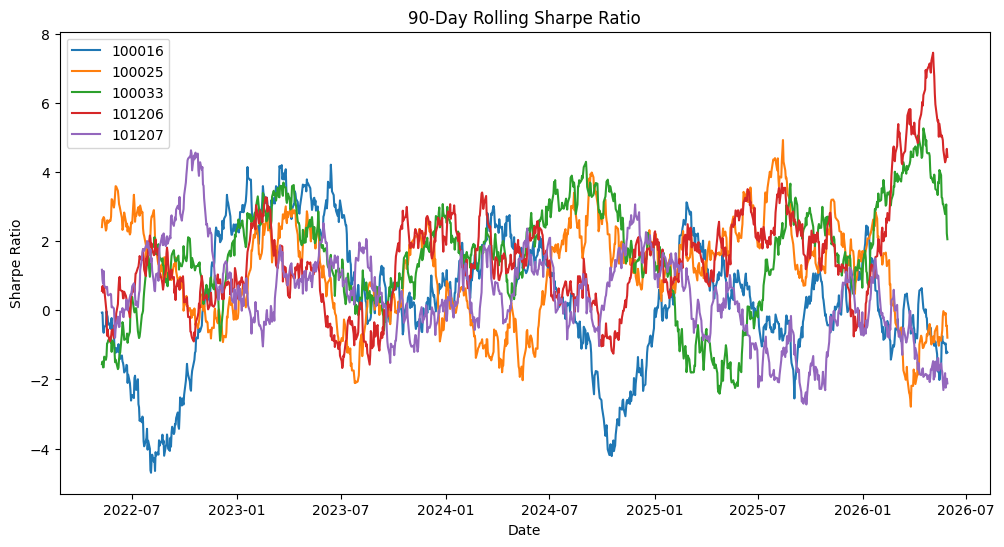

In [21]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

top_funds = (nav['amfi_code'].value_counts().head(5).index)

plt.figure(figsize=(12,6))

for fund in top_funds:

    temp = nav[nav['amfi_code'] == fund].copy()

    sharpe = (temp['daily_return'].rolling(90).mean()/temp['daily_return'].rolling(90).std()) * np.sqrt(252)

    plt.plot(temp['date'],sharpe,label=str(fund))

plt.legend()
plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.savefig("reports/rolling_sharpe_chart.png")

plt.show()

In [22]:
print(funds.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [23]:
risk_df.shape

(40, 3)

In [24]:
sharpe_df.to_csv("reports/sharpe_ratio.csv",index=False)

print("sharpe_ratio.csv saved successfully")

NameError: name 'sharpe_df' is not defined

In [25]:
sharpe_list = []

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == fund]

    returns = temp['daily_return'].dropna()

    if len(returns) > 0 and returns.std() != 0:

        sharpe = (returns.mean() / returns.std()) * np.sqrt(252)

        sharpe_list.append([fund, sharpe])

sharpe_df = pd.DataFrame(sharpe_list,columns=['amfi_code', 'sharpe_ratio'])

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,0.245276
1,100025,1.097333
2,100033,1.436947
3,101206,1.473390
4,101207,0.414625


In [26]:
sharpe_df.to_csv("reports/sharpe_ratio.csv",index=False)

print("sharpe_ratio.csv saved successfully")

sharpe_ratio.csv saved successfully
